In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [22]:
# Loading the dataset
data=pd.read_csv('..\data/processed/master_dataset.csv')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\nethi\AppData\Local\Temp\ipykernel_36888\235543467.py:2: SyntaxWarning: invalid escape sequence '\d'
  data=pd.read_csv('..\data/processed/master_dataset.csv')


In [23]:
# Creating a DataFrame
df = pd.DataFrame(data)
df.head()

,customer_id,age,gender,city,state,city_tier,occupation,monthly_income,cricket_interest_score,favorite_ipl_team,...,sports_equipment_spending_per_month_y,previous_cricket_gear_purchases,average_order_value,preferred_product_category,purchase_frequency_per_year,discount_sensitivity,cart_abandonment_rate,payment_method_preference,brand_loyalty_level,likely_to_buy_cricket_kit_y
0,CUST0001,21,Male,Mumbai,Maharashtra,Tier 1,Student,18000,8.7,Mumbai Indians,...,3200,5,4100,Bats,4,Medium,0.24,UPI,Medium,Yes
1,CUST0002,34,Female,Bengaluru,Karnataka,Tier 1,Working Professional,72000,6.2,Royal Challengers Bengaluru,...,1800,2,2200,Jerseys,2,High,0.48,Debit Card,Low,No
2,CUST0003,18,Male,Hyderabad,Telangana,Tier 1,Student,12000,9.1,Sunrisers Hyderabad,...,5400,8,7200,Full Kits,6,Low,0.12,Credit Card,High,Yes
3,CUST0004,42,Male,Jaipur,Rajasthan,Tier 2,Business,98000,5.4,Rajasthan Royals,...,900,1,1100,Accessories,1,Medium,0.29,Cash on Delivery,Low,No
4,CUST0005,27,Female,Pune,Maharashtra,Tier 1,Working Professional,56000,7.5,Chennai Super Kings,...,4100,6,5300,Shoes,5,Medium,0.21,UPI,Medium,Yes


In [24]:
# Shape of the DataFrame
print("Shape of the DataFrame:", df.shape)

Shape of the DataFrame: (3500, 58)


In [25]:
# Columns name in the master dataset
df.columns

Index(['customer_id', 'age', 'gender', 'city', 'state', 'city_tier',
       'occupation', 'monthly_income', 'cricket_interest_score',
       'favorite_ipl_team', 'favorite_player', 'Unnamed: 11',
       'preferred_streaming_platform', 'fantasy_cricket_user',
       'sports_equipment_spending_per_month_x',
       'preferred_shopping_platform_x', 'cricket_search_frequency_per_month',
       'device_type', 'digital_engagement_score',
       'likely_to_buy_cricket_kit_x', 'engagement_id', 'favorite_match_type',
       'average_match_watch_time_minutes', 'matches_watched_per_season',
       'preferred_ad_format', 'ad_click_rate',
       'sports_content_watch_hours_per_week', 'engagement_during_csk_matches',
       'engagement_during_rcb_matches', 'engagement_during_mi_matches',
       'streaming_device_preference', 'second_screen_usage',
       'social_media_activity_during_matches', 'engagement_potential_score',
       'social_id', 'preferred_social_media_platform',
       'cricket_reels_w

In [26]:
# To know the Info about the Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 58 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   customer_id                             3500 non-null   object 
 1   age                                     3500 non-null   int64  
 2   gender                                  3500 non-null   object 
 3   city                                    3500 non-null   object 
 4   state                                   3500 non-null   object 
 5   city_tier                               3500 non-null   object 
 6   occupation                              3500 non-null   object 
 7   monthly_income                          3500 non-null   int64  
 8   cricket_interest_score                  3487 non-null   float64
 9   favorite_ipl_team                       3500 non-null   object 
 10  favorite_player                         3487 non-null   obje

In [27]:
df.isnull().sum()

customer_id                                0
age                                        0
gender                                     0
city                                       0
state                                      0
city_tier                                  0
occupation                                 0
monthly_income                             0
cricket_interest_score                    13
favorite_ipl_team                          0
favorite_player                           13
Unnamed: 11                                0
preferred_streaming_platform               0
fantasy_cricket_user                       0
sports_equipment_spending_per_month_x      0
preferred_shopping_platform_x              0
cricket_search_frequency_per_month         0
device_type                                0
digital_engagement_score                  28
likely_to_buy_cricket_kit_x                0
engagement_id                              0
favorite_match_type                        0
average_ma

In [28]:
drops=['favorite_player']
# Dropping the columns which are not required for the analysis
df.drop(drops, inplace=True, axis=1)

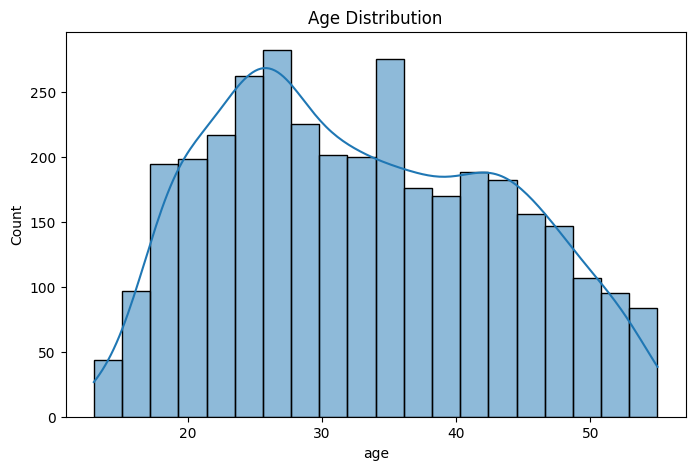

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.show()

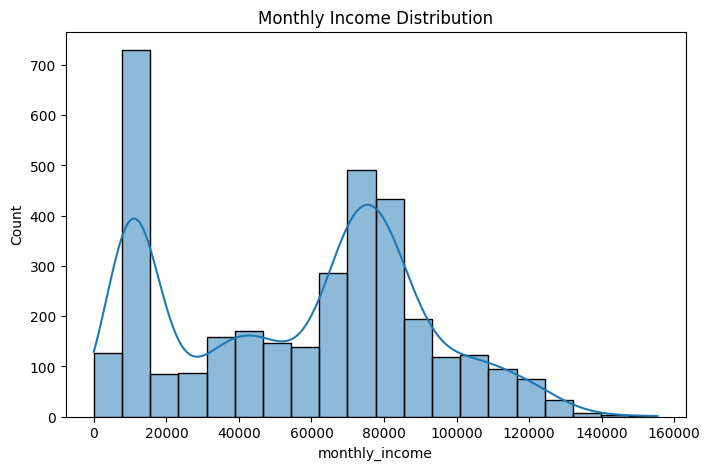

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["monthly_income"],
    bins=20,
    kde=True
)

plt.title("Monthly Income Distribution")
plt.show()

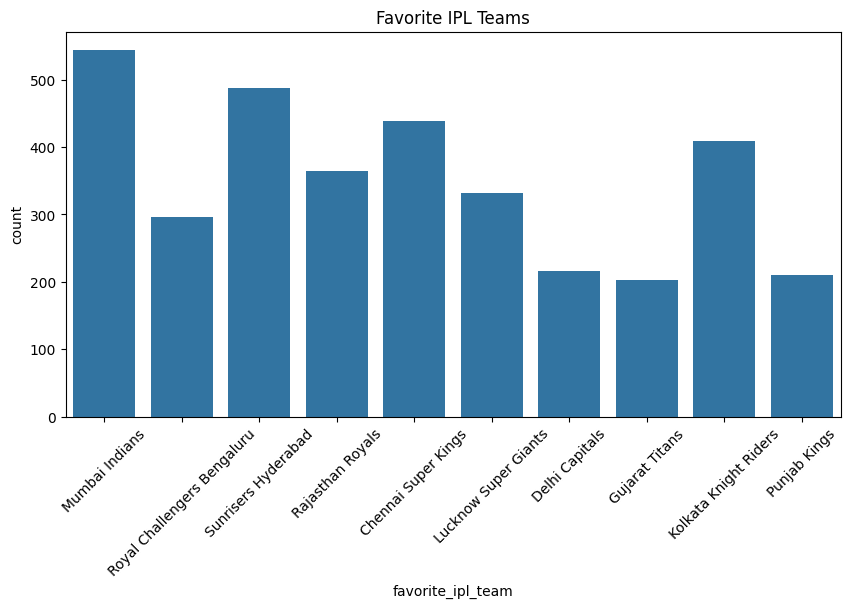

In [31]:
plt.figure(figsize=(10,5))

sns.countplot(
    x=df["favorite_ipl_team"]
)

plt.title("Favorite IPL Teams")
plt.xticks(rotation=45)
plt.show()

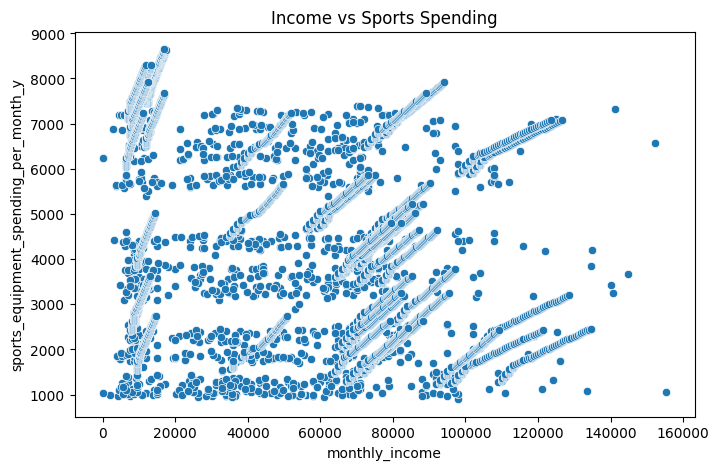

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["monthly_income"],
    y=df["sports_equipment_spending_per_month_y"]
)

plt.title("Income vs Sports Spending")
plt.show()
# Higher income individuals tend to spend more on sports equipment.

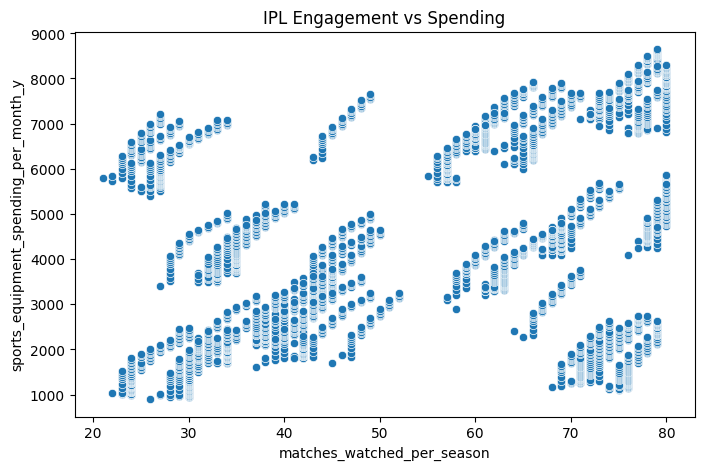

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["matches_watched_per_season"],
    y=df["sports_equipment_spending_per_month_y"]
)

plt.title("IPL Engagement vs Spending")
plt.show()
# Users with higher IPL engagement show higher sports spending.

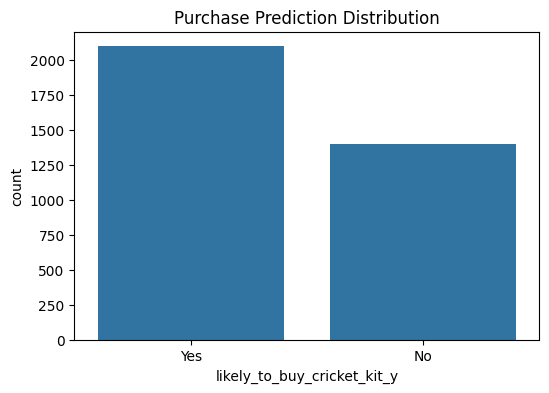

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["likely_to_buy_cricket_kit_y"]
)

plt.title("Purchase Prediction Distribution")
plt.show()
# K-Means identified 4 major customer segments.

In [38]:
num_df = df.select_dtypes(
    include=['int64', 'float64']
)

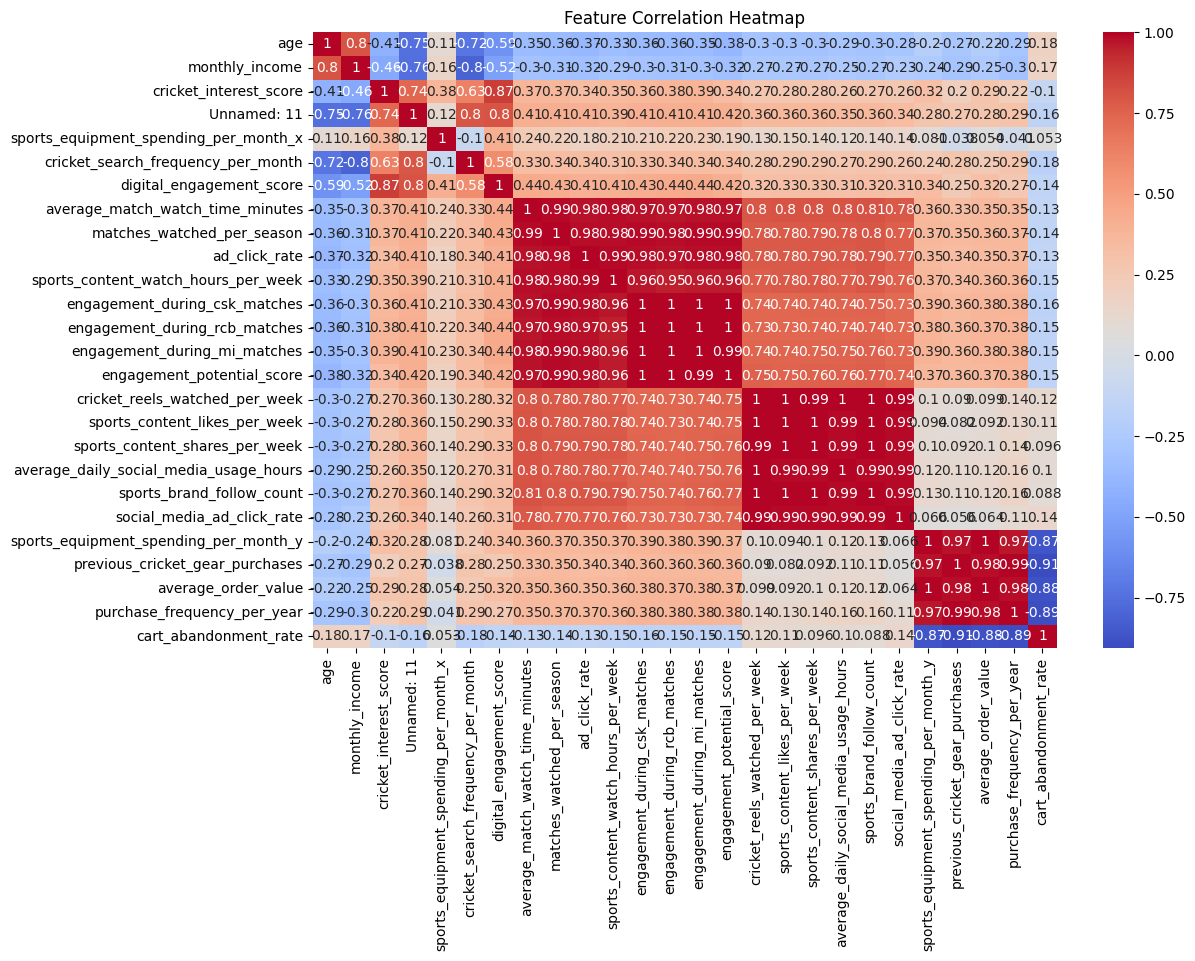

In [39]:
plt.figure(figsize=(12,8))

sns.heatmap(
    num_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [42]:
data_cluster=pd.read_csv('..\data/processed/clustered_dataset.csv')
df_cluster = pd.DataFrame(data_cluster)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\nethi\AppData\Local\Temp\ipykernel_36888\47964938.py:1: SyntaxWarning: invalid escape sequence '\d'
  data_cluster=pd.read_csv('..\data/processed/clustered_dataset.csv')


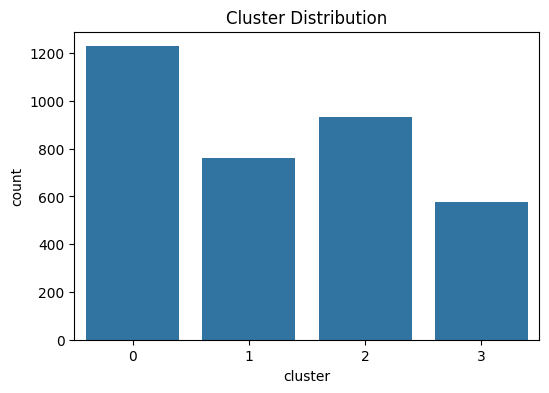

In [43]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df_cluster["cluster"]
)

plt.title("Cluster Distribution")
plt.show()

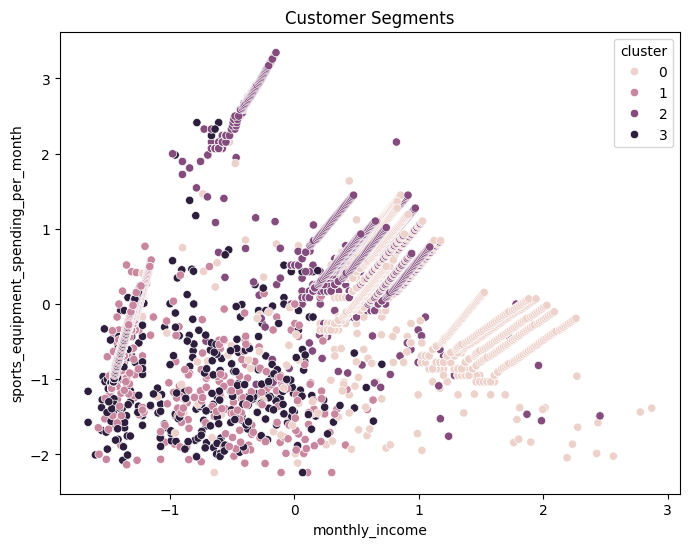

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_cluster["monthly_income"],
    y=df_cluster["sports_equipment_spending_per_month"],
    hue=df_cluster["cluster"]
)

plt.title("Customer Segments")
plt.show()